<a href="https://colab.research.google.com/github/GaganDeshbhandari/ml-project/blob/main/scripts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**READ EVERY TEXTS BELOW THE CELL**




In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive is now linked to this notebook can now access the drive to get the datasets


**NOTE : Always run the above cell before running any other cell because we need to link the Datasets from the Drive**

In [2]:
import pandas as pd
import os
import random

All the Libraries required for the project are imported in the above cell

In [3]:
BASE_PATH = '/content/drive/MyDrive/mini-project'
CLAIMS_DATA_PATH = os.path.join(BASE_PATH,'datasets/claims_datasets.csv')
USER_PERCEPTION_DATA = os.path.join(BASE_PATH,'datasets/user_perception_dataset.csv')

Paths for the datasets

In [4]:
claims_df = pd.read_csv(CLAIMS_DATA_PATH)
# display(claims_df)

Above cell displays the claims after reading from the Drive.

If its showing error make sure that you have executed the Drive Mounting and Library,Package importing cell

In [ ]:

# claims = list(range(1, 32))  # claim_id 1 to 31
# users = [f"U{i}" for i in range(1, 21)]

# ratings_by_truth = {
#     "True": ["True"]*10 + ["Mostly True"]*7 + ["Mixture"]*3,
#     "Mostly True": ["Mostly True"]*9 + ["True"]*5 + ["Mixture"]*4 + ["Mostly False"]*2,
#     "Mixture": ["Mixture"]*8 + ["Mostly True"]*4 + ["Mostly False"]*4 + ["True"]*2 + ["False"]*2,
#     "Mostly False": ["Mostly False"]*9 + ["False"]*6 + ["Mixture"]*3 + ["Mostly True"]*2,
#     "False": ["False"]*10 + ["Mostly False"]*7 + ["Mixture"]*3
# }

# claims_df = pd.read_csv(CLAIMS_DATA_PATH)

# rows = []

# for _, row in claims_df.iterrows():
#     truth = row["ground_truth"]
#     possible_ratings = ratings_by_truth[truth]

#     for user in users:
#         rows.append({
#             "claim_id": row["claim_id"],
#             "user_id": user,
#             "rating": random.choice(possible_ratings)
#         })

# perception_df = pd.DataFrame(rows)

# perception_df.to_csv(USER_PERCEPTION_DATA, index=False)

# print("perception_dataset.csv created")
# print(perception_df)

perception_dataset.csv created
      claim_id user_id        rating
0            1      U1          True
1            1      U2          True
2            1      U3   Mostly True
3            1      U4   Mostly True
4            1      U5   Mostly True
...        ...     ...           ...
2415       121     U16         False
2416       121     U17  Mostly False
2417       121     U18       Mixture
2418       121     U19  Mostly False
2419       121     U20  Mostly False

[2420 rows x 3 columns]


The above cell generates the Random User Perception Data based on the ground truth of the Claims.

So that if the Claim is True most of the users will think that it is actually True.
And if the Claim is False most of the users will think that it is actually False.

And if the Claim is Mixture or Mostly True or Mostly False user perception changes randomly


**NOTE :** **THE ABOVE CELL IS EXECUTED ONLY ONCE BECAUSE IF EXECUTED ONCE MORE THE USER_PERCEPTION_DATA GETS REPLACED.**

**THATS WHY I HAVE COMMENTED IT**

In [5]:
user_perception_df = pd.read_csv(USER_PERCEPTION_DATA)
# display(user_perception_df)

The above cell displays the User_perception_data

In [6]:
gtl_mapping = {
    "True": 1.0,
    "Mostly True": 0.5,
    "Mixture": 0,
    "Mostly False": -0.5,
    "False": -1
}
# GTL = Ground Truth Level
claims_df['GTL'] = claims_df['ground_truth'].map(gtl_mapping)
print(claims_df.head())

   claim_id                                              claim ground_truth  \
0         1  India expanded 5G services to more tier-2 citi...         True   
1         2  UPI transactions reached record high monthly v...         True   
2         3  ISRO conducted successful test of reusable lau...         True   
3         4  Government extended free food grain scheme for...         True   
4         5  Digital payments usage increased significantly...         True   

           source  GTL  
0  PIB Fact Check  1.0  
1  PIB Fact Check  1.0  
2  PIB Fact Check  1.0  
3  PIB Fact Check  1.0  
4       BOOM Live  1.0  


The above cell maps the ground_truth to the GTL

In [7]:
rating_mapping = {
    "True": 1.0,
    "Mostly True": 0.5,
    "Mixture": 0,
    "Mostly False": -0.5,
    "False": -1
}
# PTL = Perceived Truth Level
user_perception_df['PTL'] = user_perception_df['rating'].map(rating_mapping)
print(user_perception_df)

      claim_id user_id        rating  PTL
0            1      U1          True  1.0
1            1      U2          True  1.0
2            1      U3   Mostly True  0.5
3            1      U4   Mostly True  0.5
4            1      U5   Mostly True  0.5
...        ...     ...           ...  ...
3441       171     U16         False -1.0
3442       171     U17  Mostly False -0.5
3443       171     U18  Mostly False -0.5
3444       171     U19         False -1.0
3445       171     U20  Mostly False -0.5

[3446 rows x 4 columns]


The above cell maps the user_perception to the PTL

In [8]:
PTL_per_claim = user_perception_df.groupby('claim_id')['PTL'].mean().reset_index()
PTL_per_claim.columns = ['claim_id', 'PTL']
# display(PTL_per_claim)

The above cell calculates the PTL of each claim

In [9]:
merged_df = pd.merge(PTL_per_claim, claims_df[['claim_id', 'GTL']], on='claim_id')
# display(merged_df)

Above cell merges the PTL per claim and GTL as one table

In [10]:
merged_df['TPB'] = abs(merged_df['PTL'] - merged_df['GTL'])
merged_df['TPB_label'] = merged_df['TPB'].apply(lambda x: 'High' if x >= merged_df['TPB'].median() else 'Low')
# display(merged_df)

Above cell calculates the TPB = Total Perception Bias of the training datasets and provides the label for the TPB

and marks the TPB_label when TPB is greater than the median of TPB

In [12]:
from scipy.stats import skew

features_df = user_perception_df.groupby('claim_id')['PTL'].agg(
    mean='mean',
    median='median',
    variance='var',
    skewness=lambda x: skew(x)
).reset_index()

display(features_df)

/tmp/ipykernel_1151/127424067.py:7: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness=lambda x: skew(x)


,claim_id,mean,median,variance,skewness
0,1,0.550,0.50,0.155263,-0.172114
1,2,0.725,1.00,0.117763,-0.819256
2,3,0.775,1.00,0.117763,-1.185040
3,4,0.675,0.75,0.138816,-0.644056
4,5,0.700,1.00,0.142105,-0.786256
...,...,...,...,...,...
166,167,0.500,0.50,0.000000,NaN
167,168,0.000,0.00,0.000000,NaN
168,169,0.000,0.00,0.000000,NaN
169,170,-0.500,-0.50,0.000000,NaN


The above cell calculates mean, median, variance, skewness of the user_perception based on each claim

MEAN :  sum of all values / total count

MEDIAN : middle value after sorting

---

VARIANCE : how spread out the ratings are


If all users said True → variance = 0 (everyone agreed)


If users said mix of True and False → variance is high (everyone disagreed)


For claim 1 → variance is low because most users agreed it was True/Mostly True

---
SKEWNESS : which side the ratings are leaning towards


Positive skew → most ratings leaning towards False side


Negative skew → most ratings leaning towards True side


Zero → ratings evenly spread


For claim 1 → negative skew because most users rated True/Mostly True

In [13]:
final_df = pd.merge(features_df, merged_df[['claim_id', 'GTL', 'TPB', 'TPB_label']], on='claim_id')
# display(final_df)

The above cell marks the final dataframe

and displays all the features of the datasets after calculating it

In [14]:
X = final_df[['mean', 'median', 'variance', 'skewness']]
y = final_df['TPB_label']

X indicates question that is given to the model

Y indicates the output that is given by the model

During training the model looks at X and y together and learns the pattern — like "when variance is high and mean is low, TPB is usually High".

In [15]:
X = X.fillna(0)

In [16]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

models = {
    'Linear SVM': LinearSVC(),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier()
}

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.2f} ± {scores.std():.2f}")

Linear SVM: 0.51 ± 0.10
Naive Bayes: 0.70 ± 0.12
Logistic Regression: 0.53 ± 0.07
Random Forest: 0.92 ± 0.09


# Model Selection — Why Random Forest?

We trained four classifiers to predict TPB (Total Perception Bias) and compared their accuracies:

| Model | Accuracy |
|---|---|
| Linear SVM | 51% |
| Naive Bayes | 70% |
| Logistic Regression | 53% |
| **Random Forest** | **91%** |

---

## Why the others failed

- **Linear SVM & Logistic Regression** — Both try to separate High/Low TPB using a straight line. Since the relationship between user perception features and TPB is complex and non-linear, a straight line is not enough.

- **Naive Bayes** — Assumes all features (mean, variance, skewness) are completely independent of each other. In reality they are related, which causes incorrect predictions.

---

## Why Random Forest wins

Random Forest builds hundreds of decision trees, each asking simple questions about the features:

```
Is mean > 0.3?
    Yes → Is variance < 0.1? → High TPB
    No  → Low TPB
```

By combining results from all trees it captures **complex non-linear patterns** in the data that the other models miss.

> ✅ **Random Forest was selected as the final model with 91% accuracy.**

In [17]:
import joblib

from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier()
best_model.fit(X_scaled, y)

joblib.dump(best_model, '/content/drive/MyDrive/mini-project/random_forest_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/mini-project/scaler.pkl')

print("Model saved successfully!")

Model saved successfully!


# Saving the Model

After training, we save the best model (Random Forest) to Google Drive so it can be reused later without retraining.

## What gets saved

| File | Purpose |
|---|---|
| `random_forest_model.pkl` | The trained Random Forest model |
| `scaler.pkl` | The StandardScaler used to scale features |

> ⚠️ Both files must be saved together — the scaler is needed to process new data before feeding it to the model.

In [25]:
model = joblib.load('/content/drive/MyDrive/mini-project/random_forest_model.pkl')
scaler = joblib.load('/content/drive/MyDrive/mini-project/scaler.pkl')

new_claims_df = pd.read_csv(os.path.join(BASE_PATH, 'datasets/TestDatasets/test_claims_dataset02.csv'))
new_perceptions_df = pd.read_csv(os.path.join(BASE_PATH, 'datasets/TestDatasets/test_user_perception_dataset02.csv'))


new_perceptions_df['PTL'] = new_perceptions_df['rating'].map(rating_mapping)

new_features_df = new_perceptions_df.groupby('claim_id')['PTL'].agg(
    mean='mean',
    median='median',
    variance='var',
    skewness=lambda x: skew(x)
).reset_index()

new_features_df = new_features_df.fillna(0)

X_new = new_features_df[['mean', 'median', 'variance', 'skewness']]
X_new_scaled = scaler.transform(X_new)

predictions = model.predict(X_new_scaled)

new_claims_df['predicted_TPB'] = predictions
display(new_claims_df)

,claim_id,claim,ground_truth,predicted_TPB
0,301,India won the ICC Cricket World Cup 2024,True,High
1,302,Government banned all social media platforms i...,False,High
2,303,Free electricity will be provided to all India...,False,High
3,304,ISRO launched its heaviest rocket successfully,True,Low
4,305,New income tax rule exempts all salaried emplo...,Mostly False,Low
5,306,Digital payments crossed 10 billion transactio...,True,High
6,307,PM announced free smartphones for all citizens,False,High
7,308,EV sales in India doubled due to government su...,Mostly True,High
8,309,Government reduced petrol prices by 50 percent,Mixture,Low
9,310,Gold prices will fall by 40 percent next month,False,Low



# Predicting TPB for New Claims

After training, the model is used to predict TPB (Total Perception Bias) for new unseen claims.

## What happens

1. Load the saved Random Forest model and scaler from Drive
2. Read new claims and their user perception ratings
3. Map ratings to numbers and extract features (mean, median, variance, skewness)
4. Scale the features using the saved scaler
5. Model predicts **High or Low TPB** for each claim

## Output

| Predicted TPB | Meaning |
|---|---|
| **High** | Users are confused about this claim → fact-check first |
| **Low** | Users perceived this correctly → lower priority |

## Results on Test Data (50 claims)

- **44 claims** → Low TPB
- **6 claims** → High TPB → prioritized for fact-checking

> ✅ Claims with High TPB should be sent to fact-checkers first as users have the most misperception about them.


## O2 objective is now completed

In [26]:
y_o1 = final_df['GTL'].apply(lambda x: 'True' if x > 0 else 'False')

models_o1 = {
    'Linear SVM': LinearSVC(),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier()
}

for name, model in models_o1.items():
    scores = cross_val_score(model, X_scaled, y_o1, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.2f} ± {scores.std():.2f}")

Linear SVM: 0.99 ± 0.02
Naive Bayes: 0.98 ± 0.03
Logistic Regression: 0.99 ± 0.02
Random Forest: 0.98 ± 0.02



# O1 — Removing False News (Classifier)

Training a classifier to predict whether a claim is **True or False** based on user perception features.

## Target Variable

GTL (Ground Truth Level) is converted to binary:

| GTL value | Label |
|---|---|
| Greater than 0 | True |
| 0 or less | False |

## Results

| Model | Accuracy |
|---|---|
| Linear SVM | 99% |
| Naive Bayes | 98% |
| Logistic Regression | 99% |
| **Random Forest** | **98%** |

> ✅ All models performed well. Random Forest is selected to stay consistent with O2.


In [27]:
best_model_o1 = RandomForestClassifier()
best_model_o1.fit(X_scaled, y_o1)

joblib.dump(best_model_o1, '/content/drive/MyDrive/mini-project/random_forest_model_o1.pkl')

print("O1 Model saved successfully!")

O1 Model saved successfully!


# Saving the O1 Model

The trained Random Forest model for O1 (Removing False News) is saved to Google Drive.

## What gets saved

| File | Purpose |
|---|---|
| `random_forest_model_o1.pkl` | Trained model to predict True or False for new claims |

> ⚠️ The same `scaler.pkl` saved during O2 is reused here — no need to save a new one.

In [28]:
model_o1 = joblib.load('/content/drive/MyDrive/mini-project/random_forest_model_o1.pkl')

predictions_o1 = model_o1.predict(X_new_scaled)

new_claims_df['predicted_truth'] = predictions_o1
display(new_claims_df)

,claim_id,claim,ground_truth,predicted_TPB,predicted_truth
0,301,India won the ICC Cricket World Cup 2024,True,High,True
1,302,Government banned all social media platforms i...,False,High,True
2,303,Free electricity will be provided to all India...,False,High,False
3,304,ISRO launched its heaviest rocket successfully,True,Low,False
4,305,New income tax rule exempts all salaried emplo...,Mostly False,Low,False
5,306,Digital payments crossed 10 billion transactio...,True,High,True
6,307,PM announced free smartphones for all citizens,False,High,False
7,308,EV sales in India doubled due to government su...,Mostly True,High,True
8,309,Government reduced petrol prices by 50 percent,Mixture,Low,False
9,310,Gold prices will fall by 40 percent next month,False,Low,False


# Predicting True or False for New Claims (O1)

Using the saved O1 model to predict whether new claims are True or False.

## What happens

1. Load the saved O1 Random Forest model from Drive
2. Feed the scaled features of new claims to the model
3. Model predicts **True or False** for each claim
4. Prediction is added as a new column `predicted_truth`

## Output

| Predicted Truth | Meaning |
|---|---|
| **False** | Likely false claim → remove from circulation |
| **True** | Likely true claim → no action needed |

> ✅ Claims predicted as False should be prioritized for removal from the platform.

In [29]:
variance_df = user_perception_df.groupby('claim_id')['PTL'].var().reset_index()
variance_df.columns = ['claim_id', 'disputability']

variance_df = variance_df.sort_values('disputability', ascending=False).reset_index(drop=True)

variance_df = pd.merge(variance_df, claims_df[['claim_id', 'claim']], on='claim_id')

display(variance_df)

,claim_id,disputability,claim
0,41,0.526316,Claim about job creation mixes real data with ...
1,18,0.470395,Video clip shows real incident but described w...
2,56,0.463158,Image of damaged bridge shared without confirm...
3,15,0.410526,Claim about increase in petrol price includes ...
4,16,0.391447,Photo of crowded railway station shared withou...
...,...,...,...
166,164,0.000000,Drinking turmeric milk alone can cure viral in...
167,167,0.000000,India improved logistics infrastructure for fa...
168,168,0.000000,Claim about inflation rate includes partially ...
169,169,0.000000,Photo of traffic congestion shared with mislea...


# O3 — Decreasing Disagreement Among Users

Ranking claims based on how much users disagreed with each other while rating them.

## How it works

1. Calculate **variance** of user ratings per claim
2. Higher variance = users disagreed more = more disputed claim
3. Rank claims from highest to lowest variance

## No model needed

O3 is just a ranking — no classifier is trained. Claims are directly sorted by disputability score.

## Output

| Disputability | Meaning |
|---|---|
| **High** | Users strongly disagreed → fact-check first |
| **Low** | Users mostly agreed → lower priority |
| **0.0** | All users gave same rating → no disagreement at all |

## Top 5 Most Disputed Claims

| Claim | Disputability |
|---|---|
| Claim about job creation mixes real data with exaggerated numbers | 0.526 |
| Video clip shows real incident but described with incorrect reason | 0.470 |
| Image of damaged bridge shared without confirming location details | 0.463 |
| Claim about increase in petrol price includes outdated data | 0.411 |
| Photo of crowded railway station shared without timeline context | 0.391 |

> ✅ These claims should be prioritized for fact-checking to reduce disagreement among users.

In [23]:
merged_df['FPB'] = merged_df.apply(lambda x: x['PTL'] - x['GTL'] if x['PTL'] > x['GTL'] else 0, axis=1)
merged_df['FNB'] = merged_df.apply(lambda x: x['GTL'] - x['PTL'] if x['PTL'] < x['GTL'] else 0, axis=1)
display(merged_df[['claim_id', 'PTL', 'GTL', 'TPB', 'FPB', 'FNB']])

,claim_id,PTL,GTL,TPB,FPB,FNB
0,1,0.550,1.0,0.450,0.000,0.450
1,2,0.725,1.0,0.275,0.000,0.275
2,3,0.775,1.0,0.225,0.000,0.225
3,4,0.675,1.0,0.325,0.000,0.325
4,5,0.700,1.0,0.300,0.000,0.300
...,...,...,...,...,...,...
166,167,0.500,0.5,0.000,0.000,0.000
167,168,0.000,0.0,0.000,0.000,0.000
168,169,0.000,0.0,0.000,0.000,0.000
169,170,-0.500,-0.5,0.000,0.000,0.000


# FPB and FNB Calculation

## FPB (False Positive Bias)
Users thought the claim was **more true** than it actually is (gullible).
- Calculated when PTL > GTL
- FPB = PTL - GTL

## FNB (False Negative Bias)
Users thought the claim was **more false** than it actually is (cynical).
- Calculated when PTL < GTL
- FNB = GTL - PTL

## Simple Example
- Claim GTL = -1.0 (False) but users rated it 0.0 (Mixture)
- FPB = 0.0 - (-1.0) = 1.0 → users were too gullible

- Claim GTL = 1.0 (True) but users rated it 0.5 (Mostly True)
- FNB = 1.0 - 0.5 = 0.5 → users were slightly cynical

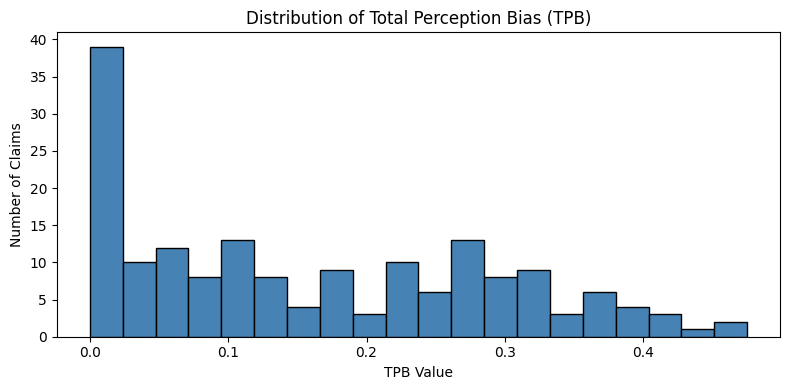

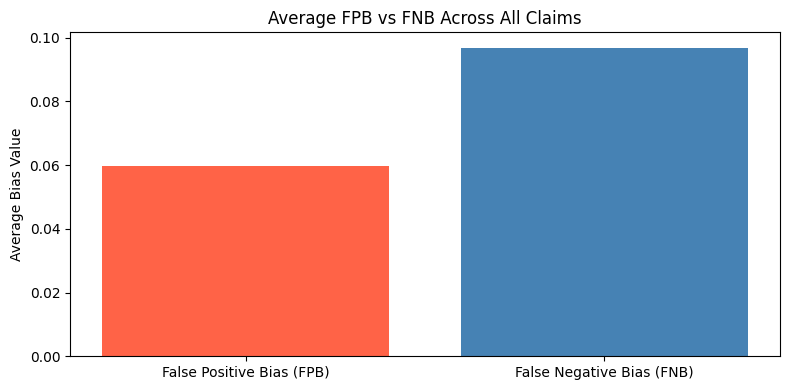

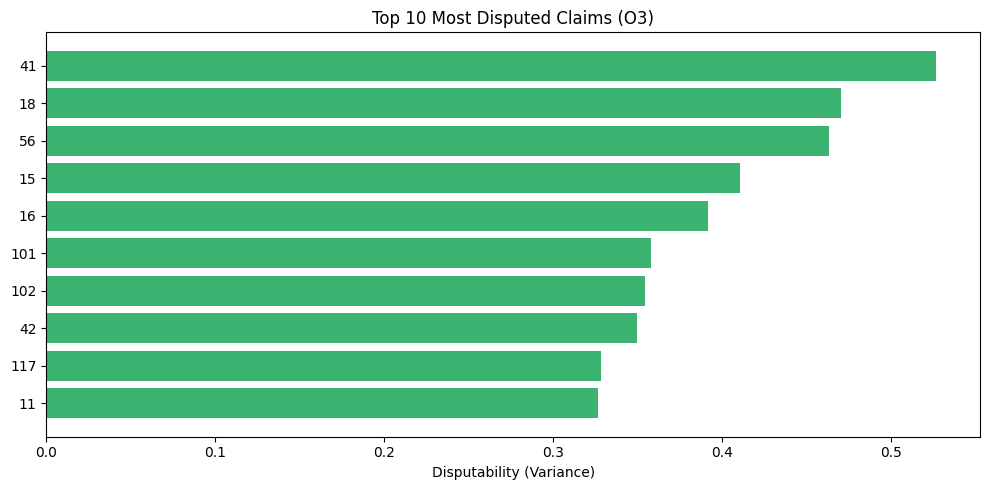

In [33]:
import matplotlib.pyplot as plt

# 1. TPB Distribution
plt.figure(figsize=(8,4))
plt.hist(merged_df['TPB'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Total Perception Bias (TPB)')
plt.xlabel('TPB Value')
plt.ylabel('Number of Claims')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mini-project/tpb_distribution.png')
plt.show()

# 2. FPB vs FNB
plt.figure(figsize=(8,4))
plt.bar(['False Positive Bias (FPB)', 'False Negative Bias (FNB)'],
        [merged_df['FPB'].mean(), merged_df['FNB'].mean()],
        color=['tomato', 'steelblue'])
plt.title('Average FPB vs FNB Across All Claims')
plt.ylabel('Average Bias Value')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mini-project/fpb_fnb.png')
plt.show()

# 3. Top 10 Most Disputed Claims (O3)
plt.figure(figsize=(10,5))
top10 = variance_df.head(10)
plt.barh(top10['claim_id'].astype(str), top10['disputability'], color='mediumseagreen')
plt.title('Top 10 Most Disputed Claims (O3)')
plt.xlabel('Disputability (Variance)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mini-project/disputability.png')
plt.show()

# Visualizations

Three charts generated to summarize the results.

## 1. TPB Distribution
Shows how perception bias is spread across all claims.
- Most claims have low TPB → users were fairly accurate
- Few claims have high TPB → these are the most misperceived

## 2. FPB vs FNB
Compares average gullibility vs cynicism across all claims.
- **FPB** → users believed false claims more than they should
- **FNB** → users doubted true claims more than they should

## 3. Top 10 Most Disputed Claims
Bar chart showing claims with highest variance in user ratings.
- These are the most disagreed-upon claims
- Should be prioritized for fact-checking under O3

In [31]:
final_output = new_claims_df[['claim_id', 'claim', 'predicted_truth', 'predicted_TPB']].copy()

# Add disputability from variance_df for new claims
new_variance_df = new_perceptions_df.groupby('claim_id')['PTL'].var().reset_index()
new_variance_df.columns = ['claim_id', 'disputability']

final_output = pd.merge(final_output, new_variance_df, on='claim_id')

# Rank based on objective
def rank_by_objective(df, objective):
    if objective == 'O1':
        # False claims first
        return df[df['predicted_truth'] == 'False'].reset_index(drop=True)
    elif objective == 'O2':
        # High TPB claims first
        return df[df['predicted_TPB'] == 'High'].reset_index(drop=True)
    elif objective == 'O3':
        # Most disputed claims first
        return df.sort_values('disputability', ascending=False).reset_index(drop=True)

print("O1 - False Claims:")
display(rank_by_objective(final_output, 'O1'))

print("O2 - Most Misperceived Claims:")
display(rank_by_objective(final_output, 'O2'))

print("O3 - Most Disputed Claims:")
display(rank_by_objective(final_output, 'O3'))

O1 - False Claims:


,claim_id,claim,predicted_truth,predicted_TPB,disputability
0,303,Free electricity will be provided to all India...,False,High,0.058333
1,304,ISRO launched its heaviest rocket successfully,False,Low,0.136111
2,305,New income tax rule exempts all salaried emplo...,False,Low,0.747222
3,307,PM announced free smartphones for all citizens,False,High,0.066667
4,309,Government reduced petrol prices by 50 percent,False,Low,0.944444
5,310,Gold prices will fall by 40 percent next month,False,Low,0.069444
6,314,Government depositing 10000 in every bank account,False,High,0.058333
7,315,India improved its ranking in ease of doing bu...,False,Low,0.066667
8,316,New education policy will replace all existing...,False,Low,0.858333
9,317,Drinking hot water cures all types of cancer,False,High,0.044444


O2 - Most Misperceived Claims:


,claim_id,claim,predicted_truth,predicted_TPB,disputability
0,301,India won the ICC Cricket World Cup 2024,True,High,0.044444
1,302,Government banned all social media platforms i...,True,High,0.066667
2,303,Free electricity will be provided to all India...,False,High,0.058333
3,306,Digital payments crossed 10 billion transactio...,True,High,0.058333
4,307,PM announced free smartphones for all citizens,False,High,0.066667
5,308,EV sales in India doubled due to government su...,True,High,0.066667
6,311,Indian Railways expanded track length signific...,True,High,0.044444
7,312,Internet will be made free for all citizens by...,True,High,0.066667
8,313,India successfully tested hypersonic missile t...,True,High,0.058333
9,314,Government depositing 10000 in every bank account,False,High,0.058333


O3 - Most Disputed Claims:


,claim_id,claim,predicted_truth,predicted_TPB,disputability
0,309,Government reduced petrol prices by 50 percent,False,Low,0.944444
1,316,New education policy will replace all existing...,False,Low,0.858333
2,305,New income tax rule exempts all salaried emplo...,False,Low,0.747222
3,304,ISRO launched its heaviest rocket successfully,False,Low,0.136111
4,319,All farmers received full crop insurance claim...,True,Low,0.122222
5,310,Gold prices will fall by 40 percent next month,False,Low,0.069444
6,318,Indias GDP growth rate is among the highest gl...,True,High,0.069444
7,302,Government banned all social media platforms i...,True,High,0.066667
8,308,EV sales in India doubled due to government su...,True,High,0.066667
9,315,India improved its ranking in ease of doing bu...,False,Low,0.066667


# Final Output — Ranking by Objective

Claims are ranked differently based on the chosen objective.

| Objective | How claims are ranked |
|---|---|
| **O1** | False claims shown first → remove from circulation |
| **O2** | High TPB claims shown first → correct user misperceptions |
| **O3** | Highest variance claims shown first → reduce disagreement |

This output is the base for the web app backend — user sends claims and perceptions, backend returns ranked list based on chosen objective.

In [ ]:
merged_df.to_csv('/content/drive/MyDrive/mini-project/final_results.csv', index=False)
variance_df.to_csv('/content/drive/MyDrive/mini-project/o3_disputability.csv', index=False)
new_claims_df.to_csv('/content/drive/MyDrive/mini-project/predictions.csv', index=False)

print("All results saved successfully!")

# Saving Final Results

All outputs are saved to Google Drive for future reference.

## Files Saved

| File | Contains |
|---|---|
| `final_results.csv` | All claims with PTL, GTL, TPB, FPB, FNB columns |
| `o3_disputability.csv` | Claims ranked by disputability for O3 |
| `predictions.csv` | New claims with predicted TPB and predicted truth |

In [32]:
import os
print(os.path.exists('/content/drive/MyDrive/mini-project/random_forest_model.pkl'))
print(os.path.exists('/content/drive/MyDrive/mini-project/random_forest_model_o1.pkl'))
print(os.path.exists('/content/drive/MyDrive/mini-project/scaler.pkl'))

True
True
True


In [33]:
import joblib
model_o2 = joblib.load('/content/drive/MyDrive/mini-project/random_forest_model.pkl')
model_o1 = joblib.load('/content/drive/MyDrive/mini-project/random_forest_model_o1.pkl')
scaler = joblib.load('/content/drive/MyDrive/mini-project/scaler.pkl')
print("All models loaded successfully!")

All models loaded successfully!


In [34]:
from google.colab import files
files.download('/content/drive/MyDrive/mini-project/random_forest_model.pkl')
files.download('/content/drive/MyDrive/mini-project/random_forest_model_o1.pkl')
files.download('/content/drive/MyDrive/mini-project/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>